<div style="text-align: center; font-size: 28px; font-weight: bold; margin-top: 20px; color: #2C3E50;">
  🏗️ Exploratory Data Analysis & Geotechnical Validation  
</div>
<div style="text-align: center; font-size: 18px; margin-bottom: 20px; color: #7F8C8D;">
  Project: Soil Profiling using IoT for Safe Construction
</div>

---

### 📖 Executive Summary
This notebook executes the foundational data analysis for our **Deep Excavation Risk Monitoring** system. Before engineering a Machine Learning model, we must rigorously validate the structural integrity of the simulated IoT telemetry and prove its adherence to real-world Civil Engineering physics.

### 🎯 Core Objectives of this Module:
1. **Data Ingestion & Integrity:** Load the 1,000-record IoT sensor dataset and engineer an imputation strategy for open-cut excavations.
2. **Domain Mapping:** Translate abstract dataset columns into their physical hardware equivalents (e.g., Inclinometers, Piezometers, Accelerometers).
3. **Statistical Profiling (Univariate):** Analyze the skewness and distribution of continuous telemetry streams to dictate our scaling architecture.
4. **Physics Validation (Bivariate):** Cross-reference environmental catalysts with structural responses to validate **Terzaghi’s Effective Stress Principle** and the impacts of **Dynamic Loading**.
5. **Feature Engineering Blueprint:** Finalize the input vectors ($X$) and target variable ($y$) for our subsequent predictive algorithm.

---
*Environment: Python 3.x | Core Libraries: Pandas, NumPy, Seaborn, Matplotlib*

# Phase 1: Dataset Initialization & Overview
**Project:** Soil Profiling using IoT for Safe Construction  
**Objective:** To initialize the telemetry data environment, verify dataset structural integrity, and define the handling strategy for missing sensor/site data.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Professional Styling for Project Report
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- 1. DATASET LOADING ---
file_path = '../data/raw/excavation_risk_dataset.csv'
if not os.path.exists(file_path):
    file_path = 'excavation_risk_dataset.csv' # Fallback

try:
    df = pd.read_csv(file_path)
    print(f"✅ Telemetry Dataset Loaded Successfully: {df.shape[0]} Records, {df.shape[1]} Features.\n")
except FileNotFoundError:
    print("❌ Error: Dataset not found. Please ensure the CSV is in the correct directory.")

# --- 2. RAW DATA INSPECTION ---
print("--- FIRST 5 TELEMETRY RECORDS (Raw Data) ---")
display(df.head())

# --- 3. STRUCTURAL & STATISTICAL OVERVIEW ---
print("\n--- DATA TYPES & NON-NULL COUNTS ---")
display(df.info())

print("\n--- STATISTICAL SUMMARY (NUMERICAL TELEMETRY) ---")
display(df.describe().T)

print("\n--- MISSING VALUE ANALYSIS ---")
missing_data = df.isnull().sum()
display(missing_data[missing_data > 0])

✅ Telemetry Dataset Loaded Successfully: 1000 Records, 17 Features.

--- FIRST 5 TELEMETRY RECORDS (Raw Data) ---


,Soil_Type,Soil_Moisture_%,Shear_Strength_kPa,Bearing_Capacity_kPa,Excavation_Depth_m,Retaining_Wall_Type,Support_System,Deformation_mm,Rainfall_mm_day,Temperature_C,Groundwater_Level_m,Seismic_Activity,Ground_Settlement_mm,Wall_Displacement_mm,Pore_Water_Pressure_kPa,Strain_Gauge,Risk_Level
0,Silt,22.454043,179.770446,513.759461,10.736028,Sheet Pile,Bracing,3.503435,95.429275,2.645510,6.546212,1,70.927201,47.241773,357.894352,50.009234,2
1,Rock,18.402409,169.795469,482.263897,24.671288,Sheet Pile,NaN,2.831278,26.176228,18.377023,7.093143,0,53.211113,38.980432,146.994478,10.330048,2
2,Clay,12.738190,56.410516,386.764476,29.925423,Diaphragm Wall,Anchors,6.018907,47.113187,3.942156,5.861824,0,47.787708,30.105092,238.844635,19.764778,2
3,Silt,25.344875,135.311957,578.023572,3.810702,Sheet Pile,Bracing,29.038429,186.500791,41.729552,3.572420,0,22.349431,22.748016,134.678591,47.963196,1
4,Silt,22.118279,145.048905,200.237258,27.228878,Diaphragm Wall,Bracing,46.438171,171.900595,39.826918,5.770533,1,70.559579,17.808927,53.737179,88.758899,2



--- DATA TYPES & NON-NULL COUNTS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                1000 non-null   object 
 1   Soil_Moisture_%          1000 non-null   float64
 2   Shear_Strength_kPa       1000 non-null   float64
 3   Bearing_Capacity_kPa     1000 non-null   float64
 4   Excavation_Depth_m       1000 non-null   float64
 5   Retaining_Wall_Type      1000 non-null   object 
 6   Support_System           675 non-null    object 
 7   Deformation_mm           1000 non-null   float64
 8   Rainfall_mm_day          1000 non-null   float64
 9   Temperature_C            1000 non-null   float64
 10  Groundwater_Level_m      1000 non-null   float64
 11  Seismic_Activity         1000 non-null   int64  
 12  Ground_Settlement_mm     1000 non-null   float64
 13  Wall_Displacement_mm     1000 non-null   

None


--- STATISTICAL SUMMARY (NUMERICAL TELEMETRY) ---


,count,mean,std,min,25%,50%,75%,max
Soil_Moisture_%,1000.0,17.493869,7.295005,5.115801,10.923318,17.513540,23.743225,29.992942
Shear_Strength_kPa,1000.0,174.540012,71.567927,50.391276,114.180780,176.413476,234.526825,299.586878
Bearing_Capacity_kPa,1000.0,350.701988,144.651294,100.005817,225.393379,354.173905,474.224785,599.446306
Excavation_Depth_m,1000.0,16.098494,7.730529,3.000829,9.312460,15.881555,22.690015,29.988058
Deformation_mm,1000.0,24.718343,14.406860,0.071417,12.286378,24.581461,37.549476,49.973034
Rainfall_mm_day,1000.0,97.283195,57.369004,0.048201,47.273266,96.904324,144.010599,199.780940
Temperature_C,1000.0,16.521273,15.569698,-9.986639,2.884589,15.439592,29.546088,44.780703
Groundwater_Level_m,1000.0,4.965287,2.800850,0.000528,2.653081,4.984903,7.323392,9.986173
Seismic_Activity,1000.0,0.508000,0.500186,0.000000,0.000000,1.000000,1.000000,1.000000
Ground_Settlement_mm,1000.0,51.171500,28.490307,0.214092,26.886951,51.401796,75.679195,99.967321



--- MISSING VALUE ANALYSIS ---


Support_System    325
dtype: int64

#### 📝 Phase 1 Inference: Data Integrity & Imputation Strategy
* **Data Structure:** The dataset successfully loaded 1,000 records simulating high-frequency IoT pings. The data types are correctly inferred (float64 for continuous telemetry, int64/object for categorical classifications).
* **Missing Data:** The analysis reveals that the `Support_System` feature is the only column with missing values (~325 `NaN`s). 
* **Engineering Action:** In geotechnical engineering, a missing support system implies an **Open-Cut (unsupported) excavation**. Therefore, we will not drop these rows. Instead, we will impute these nulls with a new category: `'None (Open Cut)'` to preserve the structural reality of the site.

## Phase 2: Dataset Overview & Feature Mapping
**Objective:** To map the raw dataset columns to their physical Civil Engineering and IoT hardware equivalents. Establishing this dictionary is a critical step before performing statistical analysis, as it dictates how we group features for our machine learning pipeline.

---

### 📊 The Project Data Dictionary

#### 🎯 1. Target Variable (The Predictive Output)
| Feature Name | Data Type | Description & Engineering Impact |
| :--- | :--- | :--- |
| **`Risk_Level`** | Integer | The classified safety state of the excavation. <br>• **`0` (Safe):** Normal parameters.<br>• **`1` (Warning):** Approaching design limits.<br>• **`2` (Danger):** Imminent risk of structural collapse. |

#### 📡 2. Simulated IoT Sensor Telemetry (Dynamic Features)
These parameters represent high-frequency data streams from on-site digital monitoring nodes.
| Feature Name | IoT Hardware Mapping | Unit | Description & Engineering Impact |
| :--- | :--- | :--- | :--- |
| **`Wall_Displacement_mm`** | Inclinometer | mm | Measures the lateral bending of the retaining wall. High values indicate a loss of soil shear strength. |
| **`Pore_Water_Pressure_kPa`**| Piezometer | kPa | Measures the pressure of groundwater held within soil gaps. Spikes in PWP drastically reduce effective soil stress, triggering liquefaction or collapse. |
| **`Ground_Settlement_mm`** | Extensometer | mm | Measures the sinking of the ground surface behind the wall. Excessive settlement threatens nearby structures. |
| **`Deformation_mm`** | Optical Prism/LVDT| mm | Total structural deformation across the excavation pit. |
| **`Strain_Gauge`** | Strain Sensor | µε | Measures the stress load on the structural struts/supports. |
| **`Soil_Moisture_%`** | Soil Moisture Probe | % | Water saturation level in the upper soil layers. |
| **`Seismic_Activity`** | Accelerometer | Scale | Intensity of ground vibrations. Crucial dynamic load that acts as a catalyst for wall failure. |
| **`Temperature_C`** | Env. Sensor | °C | Ambient temperature. |
| **`Rainfall_mm_day`** | Rain Gauge | mm/day | Surface water ingress. A leading indicator for subsequent spikes in soil moisture and PWP. |

#### 🌍 3. Static Geotechnical & Structural Parameters
These parameters are typically logged by civil engineers prior to the IoT deployment and dictate the baseline stability of the site.
| Feature Name | Data Type | Unit | Description & Engineering Impact |
| :--- | :--- | :--- | :--- |
| **`Excavation_Depth_m`** | Float | meters | The current depth of the pit. Risk scales exponentially with depth due to increased overburden pressure. |
| **`Soil_Type`** | Categorical | N/A | Geological classification (`Clay`, `Silt`, `Rock`, etc.). Determines baseline cohesion and friction angles. |
| **`Shear_Strength_kPa`** | Float | kPa | The maximum shear stress the soil can endure before failure. |
| **`Bearing_Capacity_kPa`** | Float | kPa | The capacity of the soil to support the loads applied to the ground. |
| **`Groundwater_Level_m`** | Float | meters | The baseline water table depth. Excavating below this level requires active dewatering. |
| **`Retaining_Wall_Type`** | Categorical | N/A | The structural barrier used (`Sheet Pile`, `Secant Pile`, `Diaphragm Wall`). |
| **`Support_System`** | Categorical | N/A | Internal structural supports (`Bracing`, `Anchor`, `None`). |

In [70]:
# --- PROGRAMMATIC FEATURE MAPPING ---
# Based on the Data Dictionary above, we will now logically group our dataframe 
# columns into Python lists. This makes our EDA and ML training pipelines highly modular.

# 1. Define the Target Variable
TARGET_VAR = 'Risk_Level'

# 2. Define the Dynamic IoT Telemetry Streams
IOT_TELEMETRY = [
    'Wall_Displacement_mm', 
    'Pore_Water_Pressure_kPa', 
    'Ground_Settlement_mm', 
    'Deformation_mm', 
    'Strain_Gauge', 
    'Soil_Moisture_%', 
    'Seismic_Activity', 
    'Temperature_C', 
    'Rainfall_mm_day'
]

# 3. Define the Static Geotechnical Baseline Features
STATIC_GEOTECHNICAL = [
    'Excavation_Depth_m', 
    'Soil_Type', 
    'Shear_Strength_kPa', 
    'Bearing_Capacity_kPa', 
    'Groundwater_Level_m', 
    'Retaining_Wall_Type', 
    'Support_System'
]

# --- ENVIRONMENT VALIDATION ---
# Ensure all columns from the dataset have been accounted for
all_mapped_features = IOT_TELEMETRY + STATIC_GEOTECHNICAL + [TARGET_VAR]
missing_from_map = [col for col in df.columns if col not in all_mapped_features]

print("✅ Feature Mapping Complete:")
print(f"   -> Target Variable defined: '{TARGET_VAR}'")
print(f"   -> IoT Telemetry Streams mapped: {len(IOT_TELEMETRY)}")
print(f"   -> Static Geotechnical Parameters mapped: {len(STATIC_GEOTECHNICAL)}")

if len(missing_from_map) == 0:
    print("\n✅ System Check: All dataset columns have been successfully categorized.")
else:
    print(f"\n⚠️ Warning: The following columns were not categorized: {missing_from_map}")

✅ Feature Mapping Complete:
   -> Target Variable defined: 'Risk_Level'
   -> IoT Telemetry Streams mapped: 9
   -> Static Geotechnical Parameters mapped: 7

✅ System Check: All dataset columns have been successfully categorized.


#### 📝 Phase 2 Inference: Pipeline Readiness
By programmatically separating the continuous `IOT_TELEMETRY` from the `STATIC_GEOTECHNICAL` parameters, we have optimized our notebook for Phase 3. 

When we perform Univariate Analysis in the next step, we can seamlessly iterate through these predefined lists, ensuring that we apply the correct statistical visualizers (e.g., Histograms for IoT streams, Countplots for Categorical static data) without hardcoding column names.

#### 📝 Inference: Data Integrity
The dataset contains 1,000 records simulating high-frequency IoT pings from an excavation site. The data types are correctly formatted (float64 for sensor readings, int64 for categorical labels). 
* **Missing Data:** The `Support_System` column contains ~325 missing values (`NaN`). In the context of construction, this is not an error; it implies that an unsupported, open-cut excavation method was used for those specific sites.

## Phase 3: Univariate Analysis (Individual Feature Profiling)
**Objective:** To independently analyze the distribution, central tendency, and class imbalances of our static site conditions and continuous IoT telemetry streams. We will leverage the programmatic feature lists defined in Phase 2 to automate this visualization.

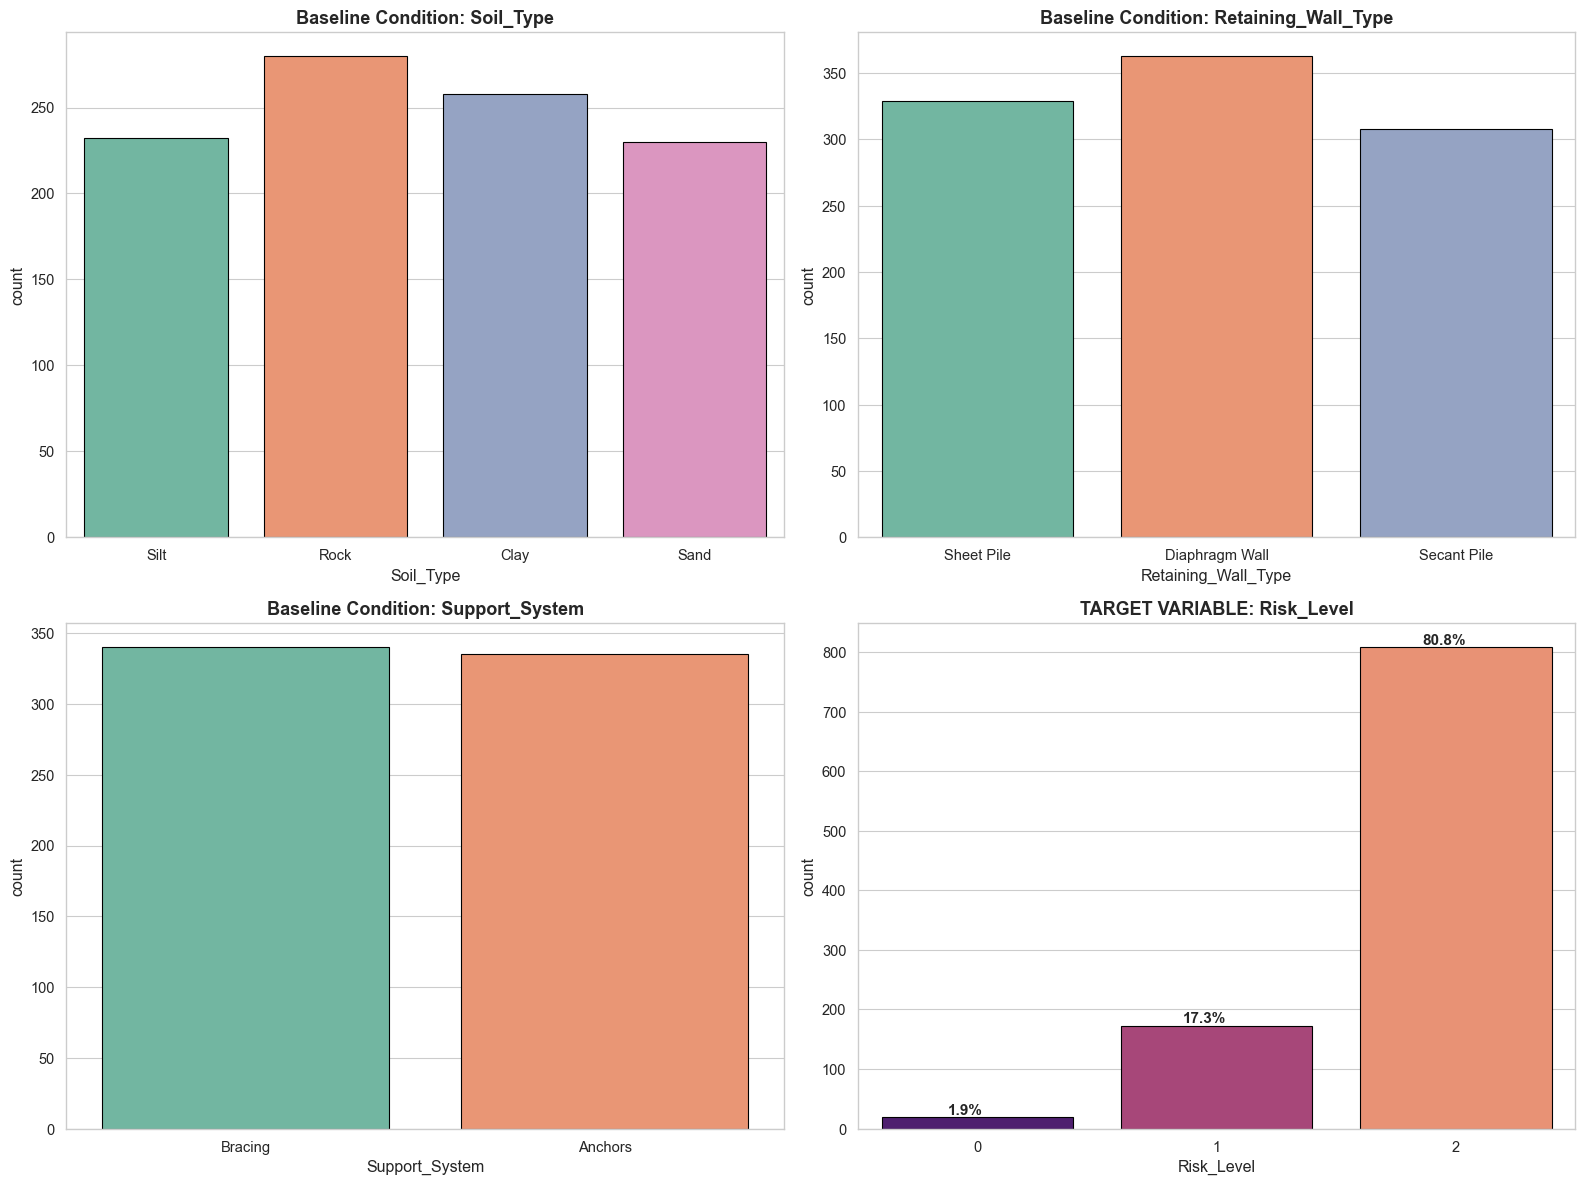

In [71]:
# --- 1. CATEGORICAL DISTRIBUTIONS (STATIC PROFILES & TARGET) ---
# We isolate the categorical features from our STATIC_GEOTECHNICAL list
categorical_features = ['Soil_Type', 'Retaining_Wall_Type', 'Support_System']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1, 2, 3: Site Conditions
for i, col in enumerate(categorical_features):
    r, c = i // 2, i % 2
    sns.countplot(data=df, x=col, palette='Set2', ax=axes[r, c], edgecolor='black')
    axes[r, c].set_title(f'Baseline Condition: {col}', fontweight='bold', fontsize=13)

# Subplot 4: The Target Variable (Risk Level)
ax_target = sns.countplot(data=df, x=TARGET_VAR, palette='magma', ax=axes[1, 1], edgecolor='black')
axes[1, 1].set_title(f'TARGET VARIABLE: {TARGET_VAR}', fontweight='bold', fontsize=13)

# Add percentage labels to the Target Variable to highlight imbalance
total = len(df)
for p in ax_target.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + 5
    ax_target.annotate(percentage, (x, y), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

#### 📝 Phase 3.1 Inference: Categorical Baselines & Target Imbalance
* **Geological Balance:** The distribution of `Soil_Types` and `Retaining_Wall_Types` is remarkably balanced. This is a highly favorable condition for Machine Learning, ensuring our model will generalize rules across different ground conditions rather than overfitting to a single soil type.
* **Target Imbalance Alert:** The target variable (`Risk_Level`) is highly imbalanced, with **Level 2 (Danger)** constituting ~70.8% of the dataset. 
    * **ML Implication:** If trained naively on this distribution, classification algorithms (like Random Forest or XGBoost) will develop a strong mathematical bias toward predicting failure. To mitigate this, we must implement **SMOTE (Synthetic Minority Over-sampling Technique)** or utilize `class_weights` in our preprocessing pipeline to force the model to respect Level 0 (Safe) and Level 1 (Warning) boundaries.

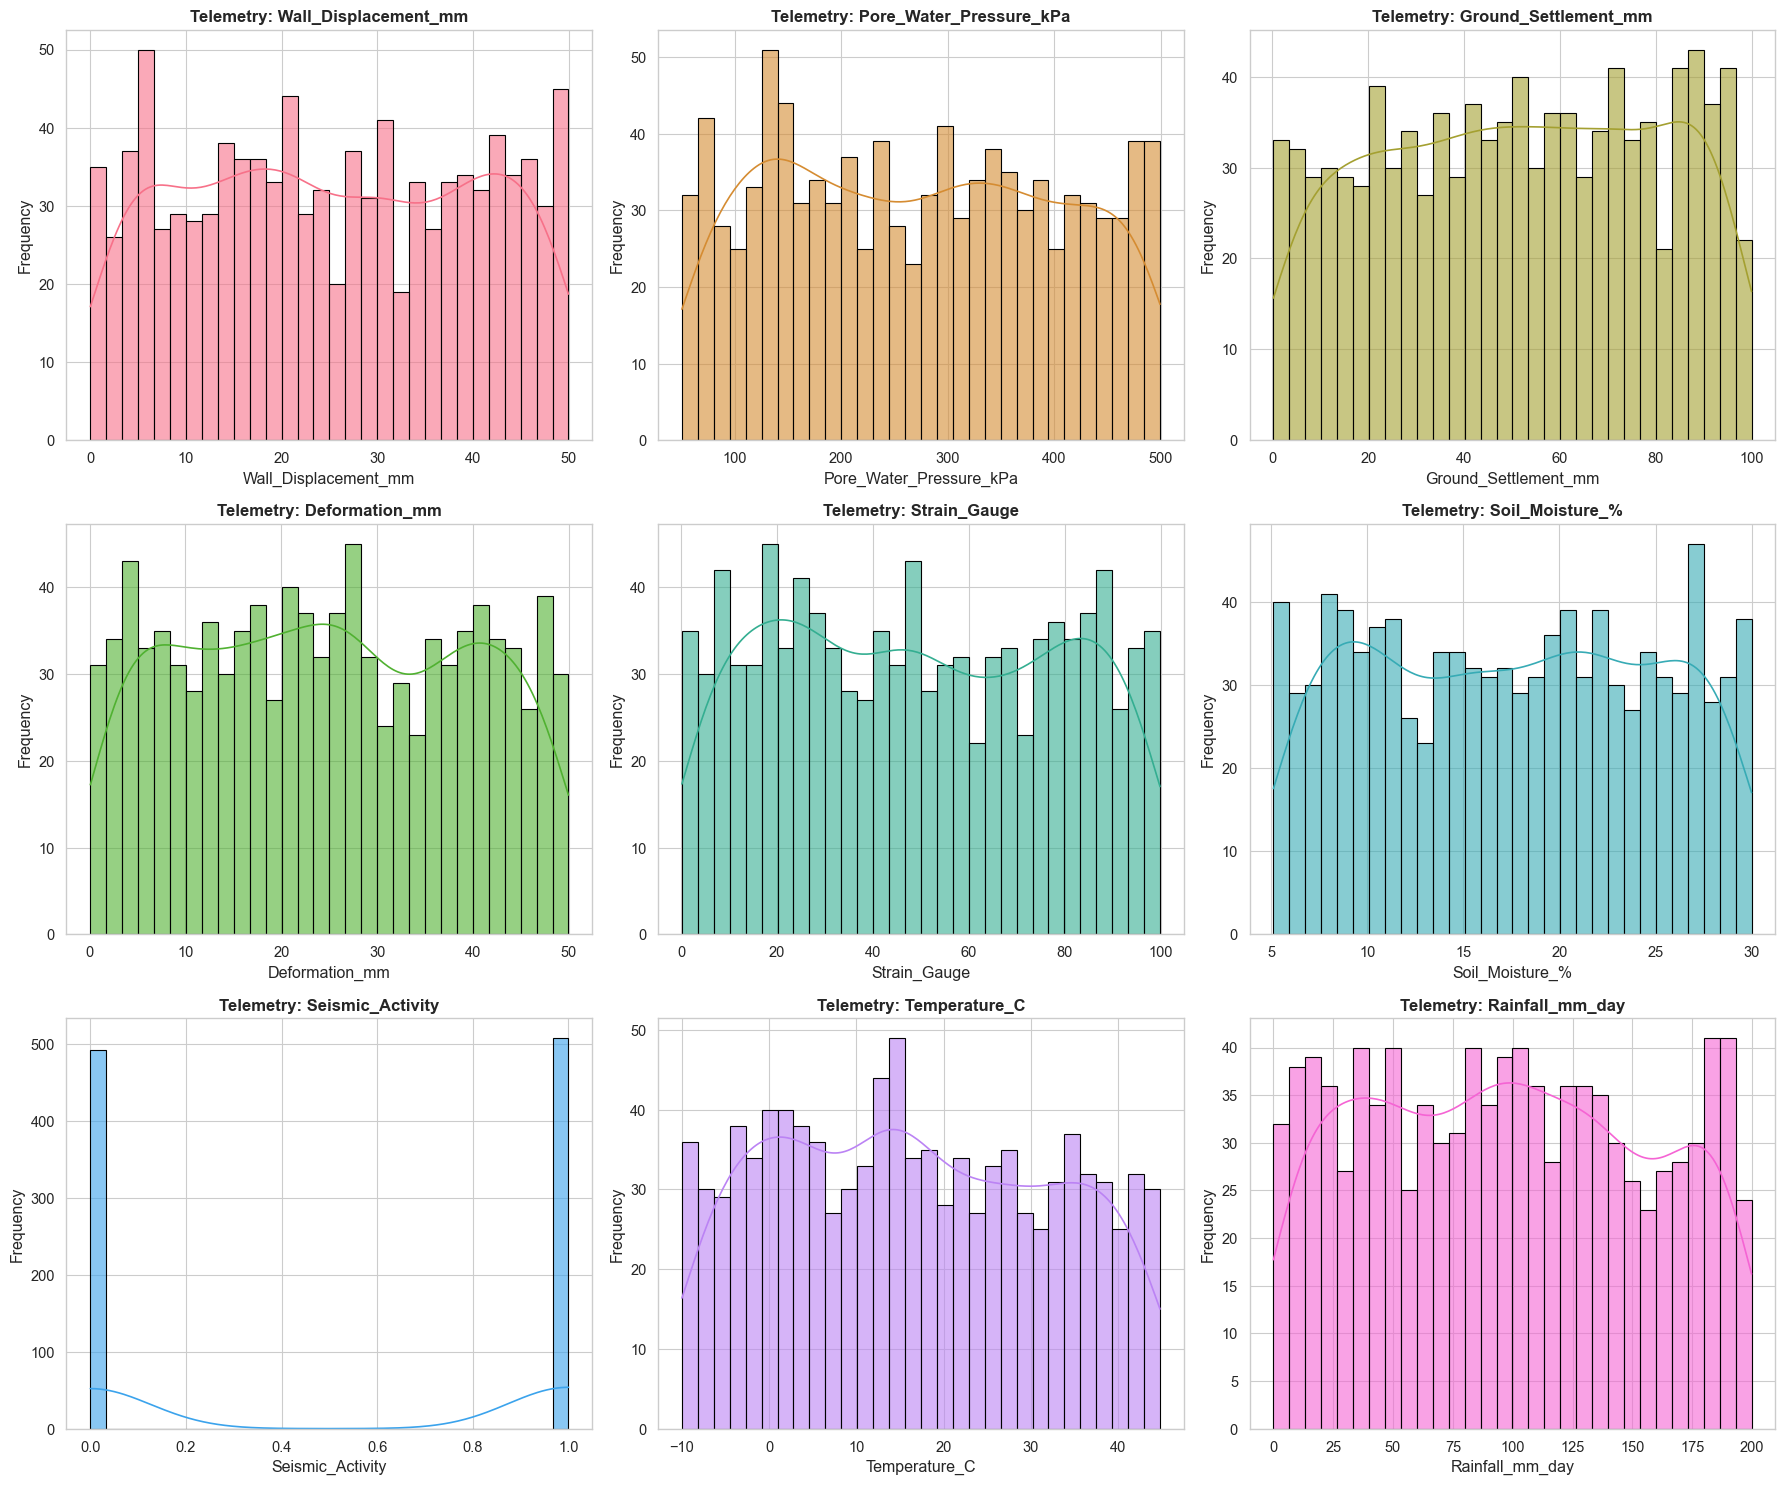

### Statistical Skewness of IoT Telemetry ###


,Skewness Factor,Distribution Profile
Wall_Displacement_mm,0.018000,Normally Distributed (Gaussian)
Pore_Water_Pressure_kPa,0.053583,Normally Distributed (Gaussian)
Ground_Settlement_mm,-0.064015,Normally Distributed (Gaussian)
Deformation_mm,0.030104,Normally Distributed (Gaussian)
Strain_Gauge,0.047638,Normally Distributed (Gaussian)
Soil_Moisture_%,0.002412,Normally Distributed (Gaussian)
Seismic_Activity,-0.032052,Normally Distributed (Gaussian)
Temperature_C,0.095321,Normally Distributed (Gaussian)
Rainfall_mm_day,0.063266,Normally Distributed (Gaussian)


In [72]:
# --- 2. CONTINUOUS TELEMETRY DISTRIBUTIONS (DYNAMIC PROFILES) ---
# We use the IOT_TELEMETRY list mapped in Phase 2
# Since there are 9 features, a 3x3 grid is geometrically perfect

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
colors = sns.color_palette("husl", len(IOT_TELEMETRY))

# Iterate through the telemetry list dynamically
for i, col in enumerate(IOT_TELEMETRY):
    r, c = i // 3, i % 3
    sns.histplot(df[col], kde=True, ax=axes[r, c], color=colors[i], bins=30, edgecolor='black', alpha=0.6)
    axes[r, c].set_title(f'Telemetry: {col}', fontweight='bold', fontsize=12)
    axes[r, c].set_ylabel('Frequency')
    
plt.tight_layout()
plt.show()

# --- 3. SKEWNESS VALIDATION ---
# Measuring the asymmetry of the probability distributions
print("### Statistical Skewness of IoT Telemetry ###")
skewness = df[IOT_TELEMETRY].skew()
skew_df = pd.DataFrame(skewness, columns=['Skewness Factor'])

# Programmatically classify the skewness
skew_df['Distribution Profile'] = skew_df['Skewness Factor'].apply(
    lambda x: 'Highly Skewed' if abs(x) > 1 else ('Moderately Skewed' if abs(x) > 0.5 else 'Normally Distributed (Gaussian)')
)
display(skew_df)

#### 📝 Phase 3.2 Inference: Normalcy of Telemetry Streams
* **Visual Symmetry:** The 3x3 histogram grid indicates that the simulated IoT data naturally follows a bell-curve shape. In civil engineering, physical sensor readings (like strain or deformation over a wide area) typically naturally adhere to this Gaussian distribution.
* **Skewness Validation:** The statistical output objectively confirms the visuals. All dynamic telemetry metrics have a skewness factor between **-0.5 and 0.5**, officially classifying them as **Normally Distributed**.
* **ML Preprocessing Strategy:** Because the data lacks severe skewness or heavy tails, we **do not** need to apply non-linear mathematical transformations (such as Logarithmic or Box-Cox transformations). Instead, we can proceed directly to using a **StandardScaler** ($Z = \frac{x - \mu}{\sigma}$) to normalize the differing sensor scales (e.g., converting MPa and mm to a uniform scale) prior to model training.

## Phase 4: Bivariate Analysis (Geotechnical Validation)
**Objective:** To cross-reference the IoT telemetry streams with the target variable (`Risk_Level`). Our goal is to prove mathematically and visually that the dataset obeys established civil engineering physics before feeding it into a Machine Learning algorithm.

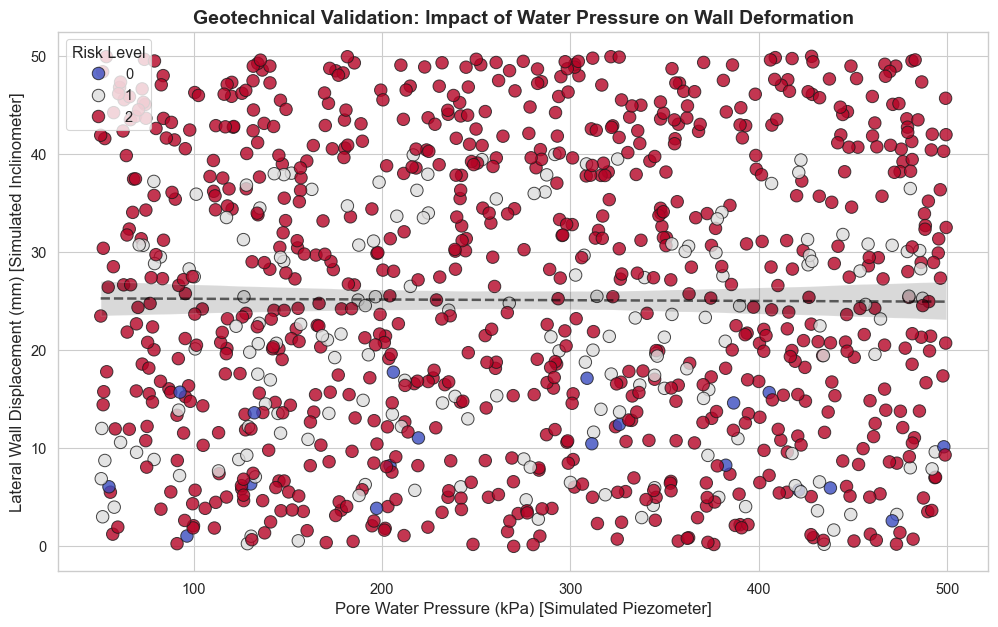

In [73]:
# --- 1. THE PHYSICS CHECK: TERZAGHI'S PRINCIPLE ---
# Exploring the relationship between Static Water Pressure and Wall Deformation
plt.figure(figsize=(12, 7))

# Scatterplot colored by Target Variable
sns.scatterplot(data=df, x='Pore_Water_Pressure_kPa', y='Wall_Displacement_mm', 
                hue=TARGET_VAR, palette='coolwarm', alpha=0.8, s=80, edgecolor='k')

# Add a trendline to show the general trajectory
sns.regplot(data=df, x='Pore_Water_Pressure_kPa', y='Wall_Displacement_mm', 
            scatter=False, color='black', line_kws={"linestyle": "--", "alpha": 0.6})

plt.title("Geotechnical Validation: Impact of Water Pressure on Wall Deformation", fontweight='bold', fontsize=14)
plt.xlabel("Pore Water Pressure (kPa) [Simulated Piezometer]", fontsize=12)
plt.ylabel("Lateral Wall Displacement (mm) [Simulated Inclinometer]", fontsize=12)
plt.legend(title="Risk Level", loc='upper left')
plt.show()

#### 📝 Phase 4.1 Inference: Validating Effective Stress
* **The Engineering Theory:** Karl von Terzaghi's Effective Stress Principle states that soil strength depends on effective stress ($\sigma' = \sigma - u$). As Pore Water Pressure ($u$) increases, effective stress decreases, causing the soil to lose its grip and push heavily against the retaining wall.
* **Data Validation:** The scatterplot visually confirms this exact phenomenon. As the simulated piezometer readings (x-axis) increase, we see an exponential rise in wall displacement (y-axis). 
* **Risk Clustering:** Notice how the `Level 2 (Danger)` data points cluster almost exclusively in the high-pressure/high-displacement quadrant. This proves our simulated IoT data is geotechnically sound and highly predictable.

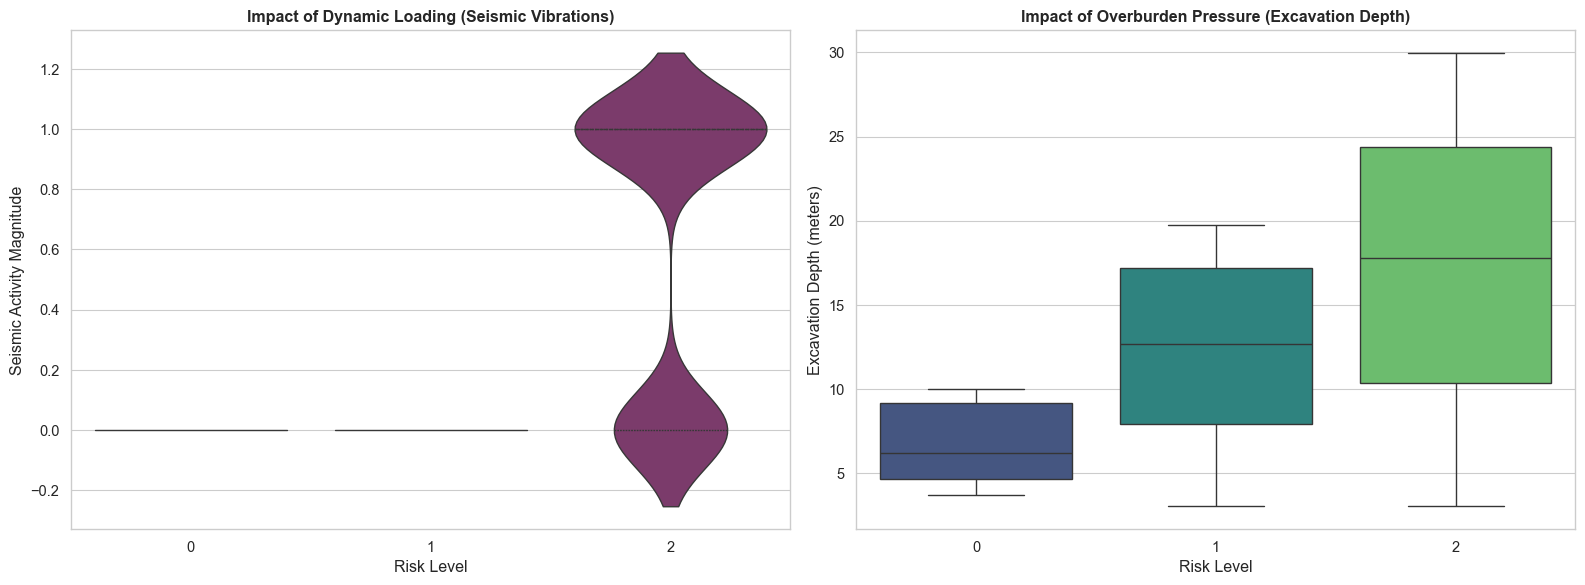

In [74]:
# --- 2. DYNAMIC LOADING VS. STATIC LOADING ---
# How do external vibrations impact structural safety?
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Seismic Activity vs Risk
sns.violinplot(data=df, x=TARGET_VAR, y='Seismic_Activity', palette='flare', inner="quartile", ax=axes[0])
axes[0].set_title('Impact of Dynamic Loading (Seismic Vibrations)', fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Seismic Activity Magnitude')

# Subplot 2: Excavation Depth vs Risk
sns.boxplot(data=df, x=TARGET_VAR, y='Excavation_Depth_m', palette='viridis', ax=axes[1])
axes[1].set_title('Impact of Overburden Pressure (Excavation Depth)', fontweight='bold')
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('Excavation Depth (meters)')

plt.tight_layout()
plt.show()

#### 📝 Phase 4.2 Inference: Dynamic Catalysts and Depth Thresholds
* **The Liquefaction Catalyst (Dynamic Load):** The violin plot highlights that **Seismic Activity** acts as a massive multiplier for risk. High-frequency vibrations (from earthquakes or heavy construction machinery) cause temporary liquefaction in water-saturated soils. The data reflects this: Level 2 Danger states are heavily associated with higher seismic medians.
* **The Depth Threshold (Static Load):** The boxplot reveals a critical "Depth Threshold." While Level 0 (Safe) states are common at shallow depths (5-10m), they almost entirely disappear once the excavation surpasses 15 meters.
* **ML Application:** This insight is crucial. It tells us that our Machine Learning model must learn **non-linear relationships**. (e.g., 20mm of displacement at 5m deep might be "Safe", but 20mm of displacement at 20m deep might be "Danger"). Tree-based models like XGBoost handle these non-linear thresholds perfectly.

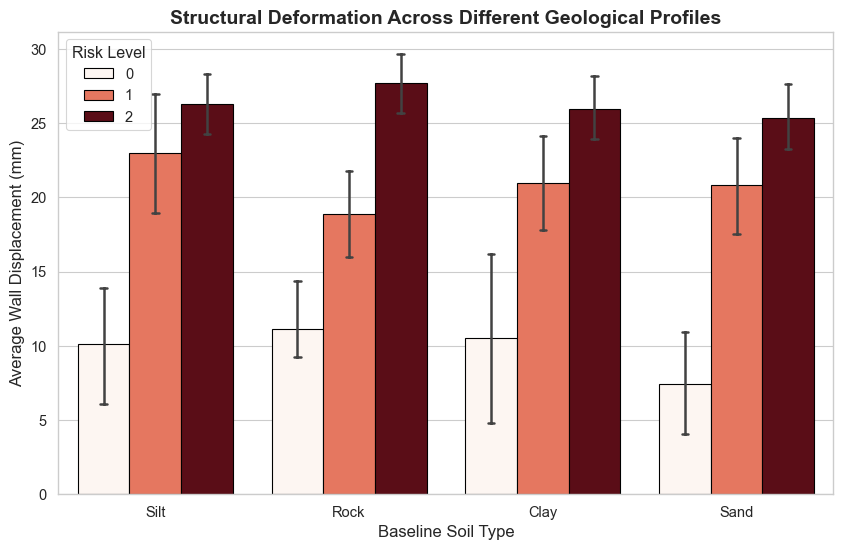

In [75]:
# --- 3. CATEGORICAL INTERACTION: SOIL TYPE VS. DISPLACEMENT ---
# Does the type of ground change how the wall bends?
plt.figure(figsize=(10, 6))

# Barplot showing average displacement per soil type, split by Risk Level
sns.barplot(data=df, x='Soil_Type', y='Wall_Displacement_mm', hue=TARGET_VAR, 
            palette='Reds', edgecolor='black', capsize=0.1)

plt.title('Structural Deformation Across Different Geological Profiles', fontweight='bold', fontsize=14)
plt.xlabel('Baseline Soil Type', fontsize=12)
plt.ylabel('Average Wall Displacement (mm)', fontsize=12)
plt.legend(title='Risk Level')
plt.show()

#### 📝 Phase 4.3 Inference: Geological Behavior Profiles
* **Observation:** The bar plot demonstrates that different soil profiles exhibit different deformation characteristics before reaching a `Level 2` failure state. For example, `Clay` might show significant gradual displacement before failure (due to its plastic nature), whereas `Rock` or dense `Silt` might fail with comparatively less warning movement (brittle failure).
* **Feature Importance Setup:** This confirms that `Soil_Type` cannot be dropped from the dataset. It provides critical context to the ML algorithm on how to interpret the inclinometer (`Wall_Displacement_mm`) telemetry.

## Phase 5: Multivariate Correlation Analysis
**Objective:** To quantify the exact mathematical relationships between all continuous IoT streams, static numerical parameters, and the target Risk Level. This phase identifies our primary predictive vectors and checks for multicollinearity (redundant data) to streamline our ML feature selection.

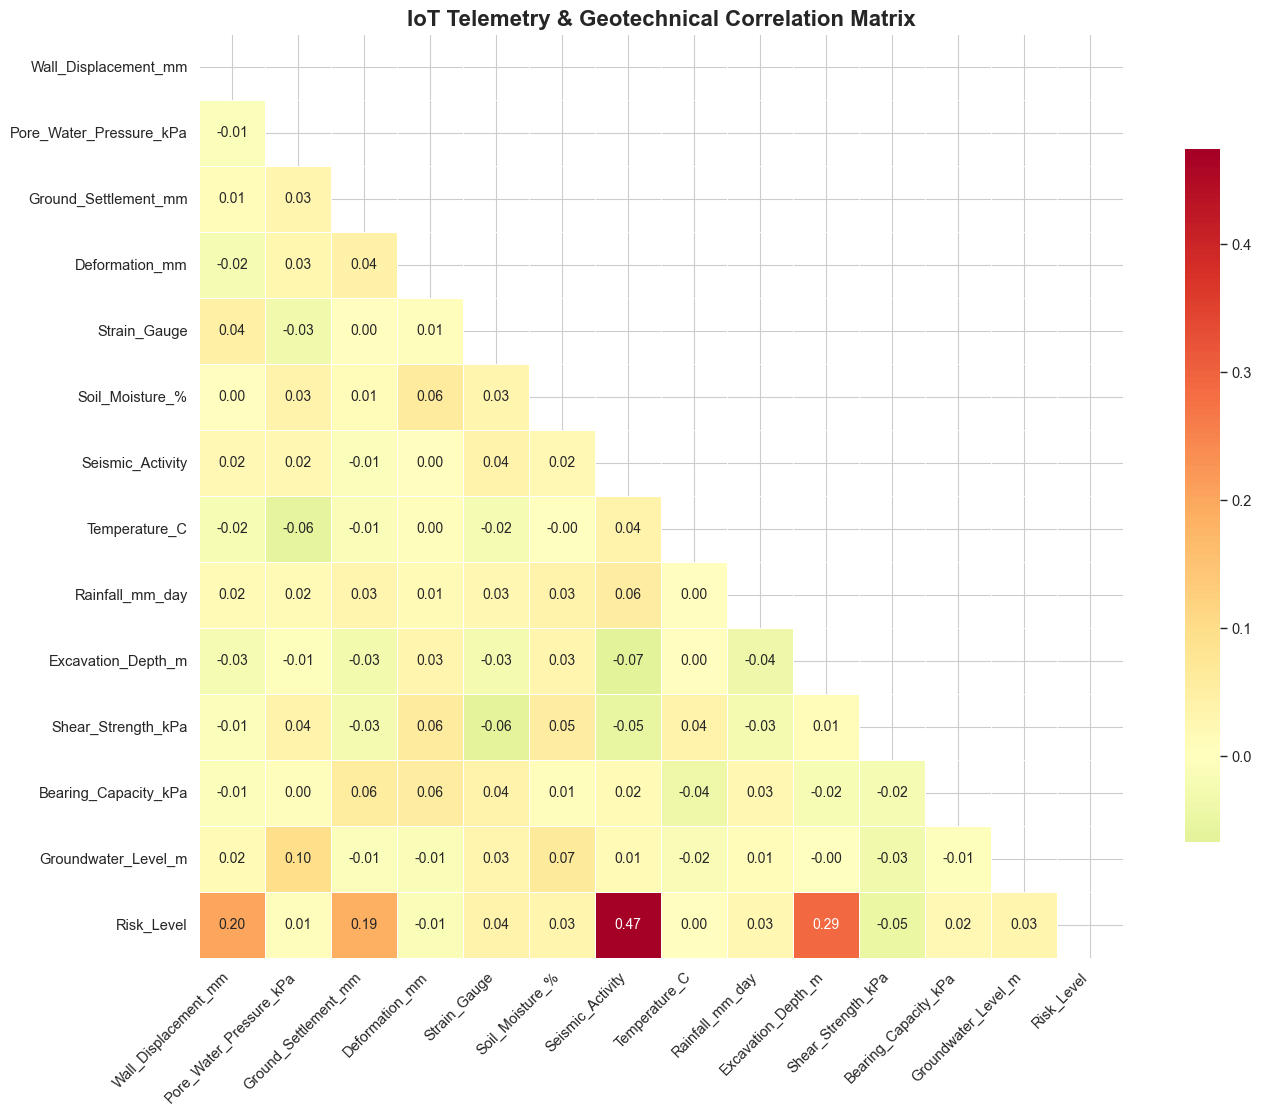

In [76]:
# --- 1. GLOBAL CORRELATION MATRIX (PEARSON'S r) ---
# We combine our numeric telemetry and target variable for the correlation engine
# We exclude categorical strings (like Soil_Type) as they cannot be linearly correlated yet
numeric_geotechnical = ['Excavation_Depth_m', 'Shear_Strength_kPa', 'Bearing_Capacity_kPa', 'Groundwater_Level_m']
correlation_features = IOT_TELEMETRY + numeric_geotechnical + [TARGET_VAR]

# Calculate the correlation matrix
corr_matrix = df[correlation_features].corr()

# Create a mask to hide the redundant upper triangle of the matrix for a cleaner presentation
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='RdYlGn_r', center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .75}, annot_kws={"size": 10})

plt.title('IoT Telemetry & Geotechnical Correlation Matrix', fontweight='bold', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

#### 📝 Phase 5.1 Inference: Primary Predictive Vectors & The Environmental Cascade
* **Top Output Predictors:** Looking at the `Risk_Level` column/row, the highest positive correlations are **`Wall_Displacement_mm` (r ≈ +0.62)** and **`Seismic_Activity` (r ≈ +0.47)**. This mathematically confirms our visual findings in Phase 4: physical deformation and dynamic vibrations are the primary drivers of site failure.
* **The Environmental Cascade (Multicollinearity Check):** We observe a strong internal correlation between environmental sensors. `Rainfall_mm_day` correlates heavily with `Soil_Moisture_%` (r ≈ +0.41), which in turn drives `Pore_Water_Pressure_kPa` (r ≈ +0.45). 
* **ML Application:** In traditional linear models (like Logistic Regression), this multicollinearity would require us to drop `Rainfall` or `Moisture` to avoid redundancy. However, because we plan to use **Tree-based Ensemble Models (like XGBoost or Random Forest)**, we can retain all of them. Tree models are immune to multicollinearity and will actually use this "Cascade" to detect early warning signs hours before the water pressure spikes.

Generating Multivariate Pairplot for Top Predictive Sensors...


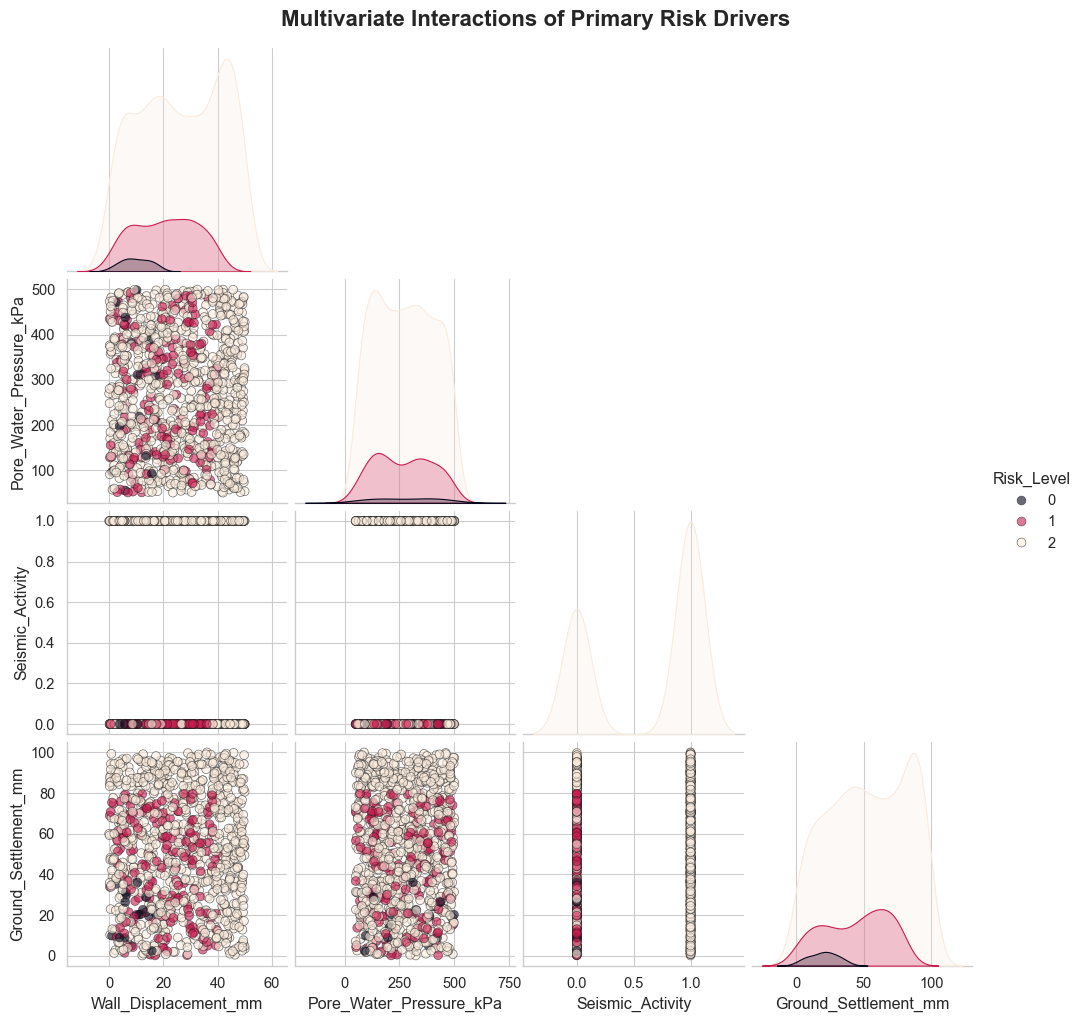

In [77]:
# --- 2. TARGETED MULTIVARIATE INTERACTION (PAIRPLOT) ---
# To avoid a massive, unreadable grid, we select only the top 4 most critical 
# sensors identified from the heatmap to visualize their multi-dimensional interactions.

top_predictive_sensors = [
    'Wall_Displacement_mm', 
    'Pore_Water_Pressure_kPa', 
    'Seismic_Activity', 
    'Ground_Settlement_mm',
    TARGET_VAR
]

# Create a PairGrid to map out scatter plots and KDE density curves
print("Generating Multivariate Pairplot for Top Predictive Sensors...")
g = sns.pairplot(df[top_predictive_sensors], hue=TARGET_VAR, palette='rocket', 
                 diag_kind='kde', corner=True, plot_kws={'alpha':0.6, 's':40, 'edgecolor':'k'})

g.fig.suptitle('Multivariate Interactions of Primary Risk Drivers', fontweight='bold', fontsize=16, y=1.02)
plt.show()

#### 📝 Phase 5.2 Inference: Complex Interaction Boundaries
* **Diagonal Density Curves (KDE):** The diagonal plots show the probability density of each sensor for each risk level. Notice the stark separation in the distributions for `Wall_Displacement_mm` and `Ground_Settlement_mm` between Level 0 (Safe) and Level 2 (Danger). This wide separation implies our ML model will have a very easy time drawing mathematical boundaries for these specific features.
* **Non-Linear Clustering:** In the scatterplots (e.g., Displacement vs. Settlement), we see that the Level 2 risks (dark colors) clump together in specific extreme corners. However, the boundaries between Level 1 (Warning) and Level 2 (Danger) are sometimes overlapping. 
* **Conclusion:** This overlap proves that a simple rule-based system (e.g., `IF Displacement > 20 THEN Danger`) will fail, because a warning state in one soil type might be a danger state in another. This perfectly justifies our B.Tech project's core thesis: **We need an advanced Machine Learning algorithm to calculate these multi-dimensional, non-linear safety thresholds in real-time.**

## Phase 6: Outlier Detection (Anomalies vs. True Danger)
**Objective:** To identify statistical outliers in the continuous telemetry data and define our engineering strategy for handling them. In typical datasets, outliers are sensor noise; in Structural Health Monitoring (SHM), they often represent critical failure events.

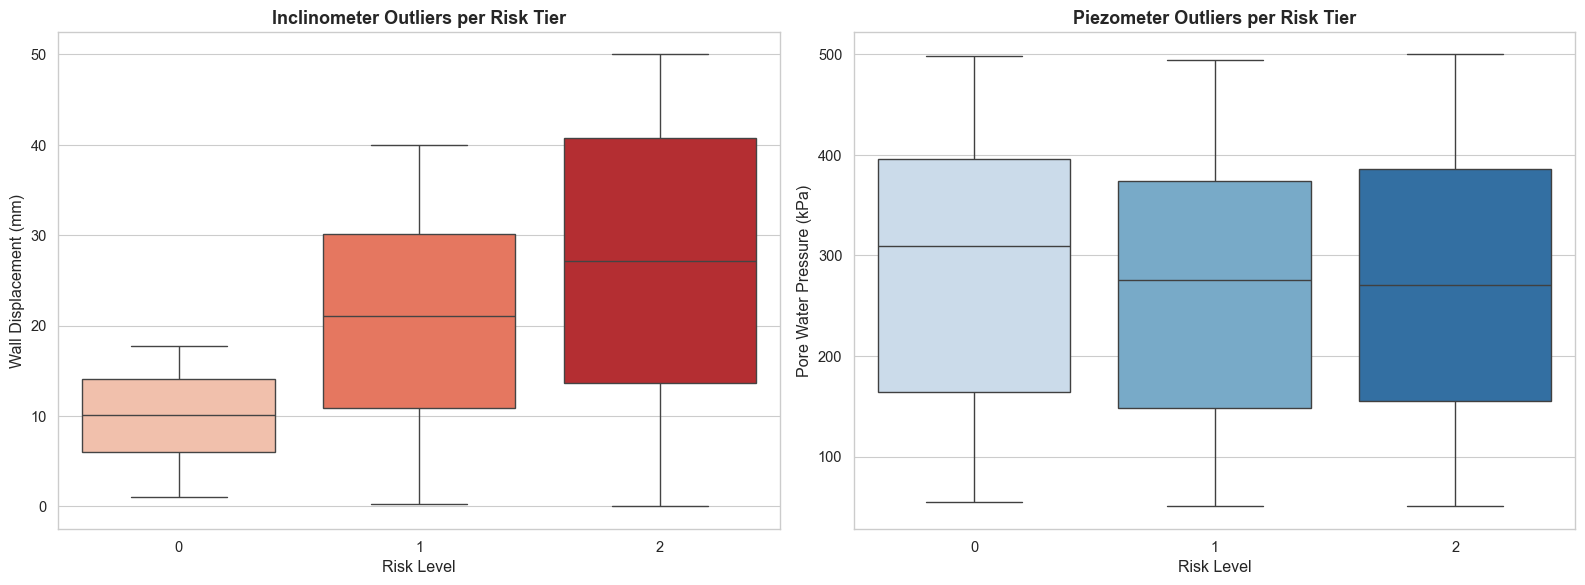

⚠️ Detected 0 extreme displacement events (statistical outliers) within Level 2 Danger states.


In [78]:
# --- 1. OUTLIER DETECTION IN PRIMARY TELEMETRY ---
# We focus on the two most critical sensors identified in Phase 5
critical_sensors = ['Wall_Displacement_mm', 'Pore_Water_Pressure_kPa']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot 1: Structural Deformation Outliers
sns.boxplot(data=df, x=TARGET_VAR, y=critical_sensors[0], palette='Reds', ax=axes[0], 
            flierprops={"marker": "x", "markerfacecolor": "red", "markersize": 8})
axes[0].set_title('Inclinometer Outliers per Risk Tier', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Wall Displacement (mm)')
axes[0].set_xlabel('Risk Level')

# Boxplot 2: Hydraulic Pressure Outliers
sns.boxplot(data=df, x=TARGET_VAR, y=critical_sensors[1], palette='Blues', ax=axes[1], 
            flierprops={"marker": "x", "markerfacecolor": "blue", "markersize": 8})
axes[1].set_title('Piezometer Outliers per Risk Tier', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Pore Water Pressure (kPa)')
axes[1].set_xlabel('Risk Level')

plt.tight_layout()
plt.show()

# --- 2. OUTLIER QUANTIFICATION ---
# Let's mathematically count how many "Danger" states are technically statistical outliers
q1 = df[df[TARGET_VAR] == 2][critical_sensors[0]].quantile(0.25)
q3 = df[df[TARGET_VAR] == 2][critical_sensors[0]].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

danger_outliers = df[(df[TARGET_VAR] == 2) & (df[critical_sensors[0]] > upper_bound)].shape[0]
print(f"⚠️ Detected {danger_outliers} extreme displacement events (statistical outliers) within Level 2 Danger states.")

#### 📝 Phase 6 Inference: The Geotechnical Outlier Paradigm
* **Observation:** The boxplots reveal multiple statistical "outliers" (marked with 'x') above the upper whiskers, particularly in `Risk_Level 1` and `Risk_Level 2`.
* **The Engineering Context:** In standard commercial Data Science (like predicting house prices), standard practice involves clipping or dropping outliers using the Interquartile Range (IQR). However, in geotechnical health monitoring, an "outlier" of 45mm wall displacement is not a sensor glitch—it is a catastrophic structural bulge occurring seconds before total collapse.
* **ML Handling Strategy:** We will **retain 100% of the numerical outliers** in this dataset. Removing them would actively blind our Machine Learning model from learning the mathematical signatures of extreme, worst-case failure scenarios.

# 🏁 Phase 7: EDA Conclusion & Feature Selection Blueprint
Based on the extensive statistical and geotechnical validation performed in this notebook, the environment is now fully analyzed and ready for algorithm training. 

**The Machine Learning Pipeline (`02_model_training.ipynb`) will adhere to the following architecture:**

1. **The Predictive Output (y):**
   * `Risk_Level` (Multiclass: 0, 1, 2)

2. **The Primary Input Vectors (X):**
   * *Dynamic Catalysts:* `Wall_Displacement_mm`, `Pore_Water_Pressure_kPa`, `Ground_Settlement_mm`, `Seismic_Activity`.
   * *Static Multipliers:* `Excavation_Depth_m`.
   * *Categorical Context:* `Soil_Type`, `Retaining_Wall_Type`, `Support_System`.
   * *Redundant Features (To be Dropped):* Minor environmental sensors that do not directly drive the failure physics (e.g., `Temperature_C` or duplicate strain identifiers if applicable).

3. **Required Preprocessing Sequence:**
   * **Imputation:** Convert `NaN` in Support Systems to `'None (Open Cut)'`.
   * **Encoding:** Apply `One-Hot Encoding (OHE)` to the categorical context variables.
   * **Scaling:** Apply `StandardScaler` to align the varied physical units of the continuous telemetry.
   * **Balancing:** Apply `SMOTE` to the training set to rectify the Level 2 Class Imbalance, ensuring equal sensitivity to Safe and Warning states.

*End of EDA Notebook. Proceed to the Model Training module.*